# **Quantitative Analysis of DSP Benchmark Variables**

The purpose of this notebook is to perform a demonstrative analysis of the results achieved in the quantitative analysis section of the paper ´´***Reclaiming Pedagogical Control in DSP Education through Hybrid-RAG-Enhanced Local LLM***``. In addition to the descriptive analysis used in the first table of the paper's quantitative analysis section (which will be generated in section 5 of this notebook), we will conduct a descriptive and inferential analysis of the **Verbosity (Tokens Out)** variable of the LLMs (Large Language Models) in section 3 (this analysis was not included in the paper) and subsequently, in section 4 of this notebook, the same analyses on the **Tokens per Second (TPS)** variable.

## **1 - Evaluation of Latency and Verbosity in Chain-of-Thought (CoT) Models**

### **1.1. Experiment Context**

This document details the data processing performed on the results of the LLM (Large Language Model) evaluation experiment in an educational context. The study compares direct inference architectures (**Raw Mode**) against an Intelligent Tutor RAG architecture (**Tutor Mode**).

The evaluated models include:
* Standard Inference Models: `Ministral-3-8B`
* Reasoning Models (Reasoning/CoT): `DeepSeek-V4-Pro` and `GPT-5`

During the exploratory analysis of latency and token data, a mathematical asymmetry was identified in the capture of metrics between the Raw Mode and the Tutor Mode, caused by the native (and often hidden) behavior of the APIs when dealing with "Reasoning Tokens".

### **1.2. The Collection Code Architecture**

The original collection *pipeline* was robustly designed using *streaming* (`stream=True`) to capture token-by-token latency. The **Time to First Token (TTFT)** metric was isolated using the following logic:

```python
for chunk in response_stream:
    # The TTFT clock only triggers when there is visible content (delta.content)
    if first_token_time is None and chunk.choices and chunk.choices[0].delta.content:
        first_token_time = time.time()
```

On the other hand, the verbosity metrics (`Tokens_Out`) were captured in different ways in the two modes of the experiment:

1. **Raw Mode (Direct API):** Pulled the final usage metadata reported by the provider's server.
`completion_tokens = usage_data.completion_tokens if usage_data else 0`
2. **Tutor Mode (Local RAG):** Since the HTTP connection via RAG did not return the usage JSON object, the tokens were estimated based on the final text rendered on the screen.
`completion_tokens = max(1, len(full_text) // 4)`

### **1.3. The Methodological Problem (The Distortion of Reasoning Models)**

The collection asymmetry generated a severe distortion in the data of `DeepSeek-V4-Pro` and `GPT-5`. These models execute a *Chain-of-Thought* (CoT) process before responding, generating thousands of invisible tokens that impacted the metrics:

* **In Raw Mode (Token Overestimation):** The reasoning model APIs embed the invisible thought *tokens* into the `completion_tokens` variable. This caused the output volume to jump to unreal values (e.g., 3,800+ tokens), when the actual read text was much smaller.
* **The Speed Illusion (Throughput):** The speed metric was calculated by `Throughput = Tokens_Out / ITL_s`. Since the `ITL_s` only captured the physical typing time of the visual text, but the `Tokens_Out` contained all the hidden reasoning generated silently, the division generated physically impossible speeds (e.g., 344 tokens/second).
* **In Tutor Mode (Relative Underestimation):** The character-based estimation ignored the reasoning. This prevented a fair comparison of verbosity between the Raw Mode and the Tutor Mode, invalidating statistical tests like Mann-Whitney on the raw data.

### **1.4. Rationale and Official Behavior of APIs**

To audit the code, we referred to the providers' official documentation at the links below:

- OpenAI: https://developers.openai.com/api/docs/guides/reasoning
- DeepSeek: https://api-docs.deepseek.com/guides/thinking_mode

The documentation confirms that the *streaming* code acted correctly by isolating the reasoning time within the TTFT, justifying the silence times of over 60 seconds before the visual response.

**A. GPT-5 Behavior (Hidden Reasoning)**
OpenAI blocks the transmission of reasoning text in the *stream*, generating a high wait time (TTFT), but charges and counts these tokens in the total.
* *Proof (OpenAI Docs):* "While reasoning tokens are not visible via the API, they still occupy space in the model's context window and are billed as output tokens. [...] The model will hold the connection open while it generates reasoning tokens, and only begin streaming chunks once the final answer begins."

**B. DeepSeek-V4-Pro Behavior (Parallel Reasoning)**
DeepSeek transmits reasoning in the stream but allocates it to a different variable (`reasoning_content`), preserving `content` strictly for the final response.
* *Proof (DeepSeek Docs):* "In the streaming mode, the reasoning process is output via the `reasoning_content` field in the `delta` object, and the final answer is output via the `content` field."
* *Code Validation:* Since our *loop* conditionally tested `if chunk.choices[0].delta.content:`, it purposefully ignored the `reasoning_content` packets. Therefore, the `TTFT` in our experiment strictly isolated the machine's cognitive silence time.

### **1.5. The Proposed Solution: Tokenization of Visible Verbosity**

To ensure an apples-to-apples comparison — focused on the **user's educational experience (Human-Computer Interaction)** — it was proposed to discard the raw API metadata. The "reasoning effort" will be strictly analyzed as Silence Latency (`TTFT_s`).

For the Verbosity (`Tokens_Out`) and Speed (`Throughput`) metrics, we will apply a standard tokenizer (`cl100k_base`) only to the final generated response (`Resposta_Gerada`). This will clear the distortion of the CoT models and unify the measuring stick between the Raw Mode and the Tutor Mode:

In [1]:
import tiktoken
import pandas as pd

def count_visible_tokens(text):
    if pd.isna(text):
        return 0
    return len(enc.encode(str(text)))

def load_and_clean(dataframe_list, test_mode):
    """Processes the already loaded DataFrames"""
    df_list = []

    for df in dataframe_list:
        if df is None or df.empty:
            continue

        # Creates the Mode column
        df['Modo'] = test_mode

        # 1. Renames the models
        df['Modelo_Limpo'] = df['Modelo'].replace(model_names)

        # 2. Creates the elegant variation
        df['Variacao'] = df['Modelo_Limpo'] + " - " + df['Idioma']

        # 3. Real tokenization of the generated text
        df['Tokens_Out'] = df['Resposta_Gerada'].apply(count_visible_tokens)

        # 4. Recalculates the Real Throughput
        df['Throughput_tps'] = df.apply(
            lambda row: row['Tokens_Out'] / row['ITL_s'] if row['ITL_s'] > 0 else 0,
            axis=1
        )

        # Removes problematic questions (if they exist)
        df = df.drop(index=[9, 69], errors='ignore')

        df_list.append(df)

    if df_list:
        return pd.concat(df_list, ignore_index=True)
    else:
        return pd.DataFrame()  # Returns empty DataFrame if there is no data

### **1.6. Documentary and Bibliographic References**

1. **OpenAI. (2026).** *Reasoning models.* Official API documentation describing the billing and latency of invisible tokens during the Chain-of-Thought in GPT-5 models. Available at: [https://platform.openai.com/docs/guides/reasoning](https://platform.openai.com/docs/guides/reasoning)

2. **DeepSeek. (2026).** *Thinking Mode.* Official documentation detailing the streaming mode and the segregation of the `reasoning_content` and `content` variables in delta objects. Available at: [https://api-docs.deepseek.com/guides/thinking_mode](https://api-docs.deepseek.com/guides/thinking_mode)

3. **Artificial Analysis. (2026).** *Language Model API Performance Benchmarking Methodology.* Methodological standardization platform suggesting the separation between the Time to First Token (TTFT) and Throughput (Output Speed) for CoT models. Available at: [https://artificialanalysis.ai/methodology/performance-benchmarking](https://artificialanalysis.ai/methodology/performance-benchmarking)

Now we apply this to the datasets

## **2. Data Import and Cleanup**

With the explanations above, from now on we will take the actions proposed in the codes below:

In [2]:
####### necessary packages ########
import numpy as np
import seaborn as sns
from io import StringIO
import requests
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, t, bootstrap

# Forces the use of TrueType fonts (Type 42) for PDF eXpress/IEEE compatibility
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['text.usetex'] = False

# Initializes the tokenizer as a global variable or inside the function
enc = tiktoken.get_encoding("cl100k_base")

# configurations to display all rows of the DataFrame
pd.set_option('display.max_rows', None)

We will import the data generated for the experiment directly from the quantitative analysis data folder of the [paper's github](https://github.com/CAIO-LIMA-37/Intelligent_Tutor_System_DSP) repository. The codes below allow anyone to import the data to be pre-processed for future treatments and descriptive and inferential analyses:

In [3]:
# GitHub Configuration
GITHUB_USER = "CAIO-LIMA-37"
REPO_NAME = "Intelligent_Tutor_System_DSP"
BRANCH = "main"
DATA_FOLDER = "quantitative/data_experiments"

def read_csv_from_github(file_path):
    """Downloads a CSV directly from GitHub and returns a DataFrame"""
    url = f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}/{file_path}"

    print(f" Downloading: {file_path.split('/')[-1]}")

    try:
        response = requests.get(url)
        response.raise_for_status()  # Checks for errors

        # Reads the CSV from the downloaded content
        df = pd.read_csv(StringIO(response.text))
        print(f"   {len(df)} rows loaded")
        return df

    except requests.exceptions.RequestException as e:
        print(f"    Error downloading {file_path}: {e}")
        return None

def list_github_files():
    """Lists all CSVs in the GitHub folder"""
    # Uses the GitHub API to list files
    api_url = f"https://api.github.com/repos/{GITHUB_USER}/{REPO_NAME}/contents/{DATA_FOLDER}"

    try:
        response = requests.get(api_url)
        response.raise_for_status()
        files = response.json()

        # Filters only .csv files
        csv_files = [f['path'] for f in files if f['name'].endswith('.csv')]

        print(f" Found {len(csv_files)} CSV files in {DATA_FOLDER}:")
        for f in csv_files:
            print(f"   - {f.split('/')[-1]}")

        return csv_files

    except requests.exceptions.RequestException as e:
        print(f" Error listing files: {e}")
        return []

In [4]:
# Dictionary to shorten and clean the model names
model_names = {
    "cyankiwi/Ministral-3-8B-Instruct-2512-AWQ-8bit": "Ministral3-8B",
    "deepseek-v4-pro": "DeepSeek-V4-Pro",
    "gpt-5": "GPT-5"
}

In [5]:
print("Starting GitHub data pipeline...")
print(f"Repository: {GITHUB_USER}/{REPO_NAME}")
print(f"Folder: {DATA_FOLDER}")
print()

# Lists all available CSV files
csv_files = list_github_files()

if not csv_files:
    print(" No CSV file found!")
else:
    # Downloads and organizes the files
    raw_files = []
    tutor_files = []

    for file in csv_files:
        df = read_csv_from_github(file)

        if df is not None:
            # Classifies between raw and tutor based on the file name
            if 'bruto' in file.lower():
                raw_files.append(df)
            elif 'tutor' in file.lower():
                tutor_files.append(df)

    print(f"\n Processing data:")
    print(f"   - {len(raw_files)} Raw mode files")
    print(f"   - {len(tutor_files)} Tutor mode files")

    # Processes the DataFrames
    if raw_files:
        df_raw = load_and_clean(raw_files, "Raw")
        print(f"\n Raw data processed: {len(df_raw)} records")
    else:
        df_raw = pd.DataFrame()
        print("\n No Raw data found")

    if tutor_files:
        df_tutor = load_and_clean(tutor_files, "Tutor")
        print(f" Tutor data processed: {len(df_tutor)} records")
    else:
        df_tutor = pd.DataFrame()
        print(" No Tutor data found")

    # Displays first rows for verification
    if not df_raw.empty:
        print(f"\n Raw data preview:")
        print(df_raw[['Modelo_Limpo', 'Idioma', 'Tokens_Out', 'Throughput_tps']].head())

    if not df_tutor.empty:
        print(f"\n Tutor data preview:")
        print(df_tutor[['Modelo_Limpo', 'Idioma', 'Tokens_Out', 'Throughput_tps']].head())

Starting GitHub data pipeline...
Repository: CAIO-LIMA-37/Intelligent_Tutor_System_DSP
Folder: quantitative/data_experiments

 Found 6 CSV files in quantitative/data_experiments:
   - geracao_bruto_cyankiwi_Ministral-3-8B-Instruct-2512-AWQ-8bit_pergunta_pt_pergunta_en_COMPLETO.csv
   - geracao_bruto_deepseek-v4-pro_pergunta_pt_pergunta_en_COMPLETO.csv
   - geracao_bruto_gpt-5_pergunta_pt_pergunta_en_COMPLETO.csv
   - geracao_tutor_cyankiwi_Ministral-3-8B-Instruct-2512-AWQ-8bit_pergunta_pt_pergunta_en_COMPLETO.csv
   - geracao_tutor_deepseek-v4-pro_pergunta_pt_pergunta_en_COMPLETO.csv
   - geracao_tutor_gpt-5_pergunta_pt_pergunta_en_COMPLETO.csv
 Downloading: geracao_bruto_cyankiwi_Ministral-3-8B-Instruct-2512-AWQ-8bit_pergunta_pt_pergunta_en_COMPLETO.csv
   120 rows loaded
 Downloading: geracao_bruto_deepseek-v4-pro_pergunta_pt_pergunta_en_COMPLETO.csv
   120 rows loaded
 Downloading: geracao_bruto_gpt-5_pergunta_pt_pergunta_en_COMPLETO.csv
   120 rows loaded
 Downloading: geracao_tuto

## **3 - Analysis of the Verbosity Variable (Tokens Out)**

### **3.1 - Summary Table (Descriptive Statistics)**

In [6]:
df_total = pd.concat([df_raw, df_tutor], ignore_index=True)

summary_table = df_total.groupby(['Modo', 'Variacao'])['Tokens_Out'].agg(
    Mean='mean',
    Median='median',
    Standard_Deviation='std',
    Minimum='min',
    Maximum='max'
).round(2).reset_index()

In [7]:
print("="*60)
print("TABLE 1: Verbosity (Generated Tokens)")
print("="*60)
display(summary_table) # Shows the beautiful table in Jupyter for your advisor

TABLE 1: Verbosity (Generated Tokens)


,Modo,Variacao,Mean,Median,Standard_Deviation,Minimum,Maximum
0,Raw,DeepSeek-V4-Pro - EN,476.39,435.0,274.22,73,1583
1,Raw,DeepSeek-V4-Pro - PT,559.39,519.0,327.20,54,1565
2,Raw,GPT-5 - EN,292.29,232.0,180.84,65,904
3,Raw,GPT-5 - PT,362.64,275.0,270.12,49,1506
4,Raw,Ministral3-8B - EN,2387.02,1196.0,5407.29,226,31068
5,Raw,Ministral3-8B - PT,1868.71,1182.0,3990.77,318,31519
6,Tutor,DeepSeek-V4-Pro - EN,618.39,542.0,317.51,42,1861
7,Tutor,DeepSeek-V4-Pro - PT,802.14,794.0,424.28,47,2499
8,Tutor,GPT-5 - EN,901.29,887.0,461.40,116,2008
9,Tutor,GPT-5 - PT,1076.76,1034.0,557.97,174,2493


### **3.2 - Normality Analysis (Shapiro-Wilk)**

In [8]:
print("\n" + "="*60)
print("TABLE 2: Shapiro-Wilk Normality Test (Alpha = 0.10)")
print("="*60)

normal_groups = True

for mode, df_mode in [("Raw", df_raw), ("Tutor", df_tutor)]:
    for variation in df_mode['Variacao'].unique():
        data = df_mode[df_mode['Variacao'] == variation]['Tokens_Out'].dropna()
        stat, p_value = shapiro(data)

        is_normal = p_value > 0.10
        if not is_normal:
            normal_groups = False

        status = "NORMAL" if is_normal else "NOT NORMAL"
        print(f"[{mode}] {variation:^30} | p-value: {p_value:.4f} -> {status}")

print("\nNormality Conclusion:")
if normal_groups:
    print("All groups follow a normal distribution. We will use the T-TEST for comparison.")
else:
    print("At least one group violated normality. We will use the MANN-WHITNEY TEST.")


TABLE 2: Shapiro-Wilk Normality Test (Alpha = 0.10)
[Raw]       Ministral3-8B - PT       | p-value: 0.0000 -> NOT NORMAL
[Raw]       Ministral3-8B - EN       | p-value: 0.0000 -> NOT NORMAL
[Raw]      DeepSeek-V4-Pro - PT      | p-value: 0.0141 -> NOT NORMAL
[Raw]      DeepSeek-V4-Pro - EN      | p-value: 0.0002 -> NOT NORMAL
[Raw]           GPT-5 - PT           | p-value: 0.0000 -> NOT NORMAL
[Raw]           GPT-5 - EN           | p-value: 0.0007 -> NOT NORMAL
[Tutor]       Ministral3-8B - PT       | p-value: 0.0278 -> NOT NORMAL
[Tutor]       Ministral3-8B - EN       | p-value: 0.0000 -> NOT NORMAL
[Tutor]      DeepSeek-V4-Pro - PT      | p-value: 0.0013 -> NOT NORMAL
[Tutor]      DeepSeek-V4-Pro - EN      | p-value: 0.0015 -> NOT NORMAL
[Tutor]           GPT-5 - PT           | p-value: 0.0498 -> NOT NORMAL
[Tutor]           GPT-5 - EN           | p-value: 0.2255 -> NORMAL

Normality Conclusion:
At least one group violated normality. We will use the MANN-WHITNEY TEST.


### **3.3. Graphical Analysis**

/tmp/ipykernel_32080/3843677574.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='Variacao', y='Tokens_Out', order=raw_order, ax=axes[0], palette="Blues_r")
/tmp/ipykernel_32080/3843677574.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_32080/3843677574.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tutor, x='Variacao', y='Tokens_Out', order=tutor_order, ax=axes[1], palette="Oranges_r")
/tmp/ipykernel_32080/3843677574.py:18: UserWarning: set_ticklabels() should only be used with a 

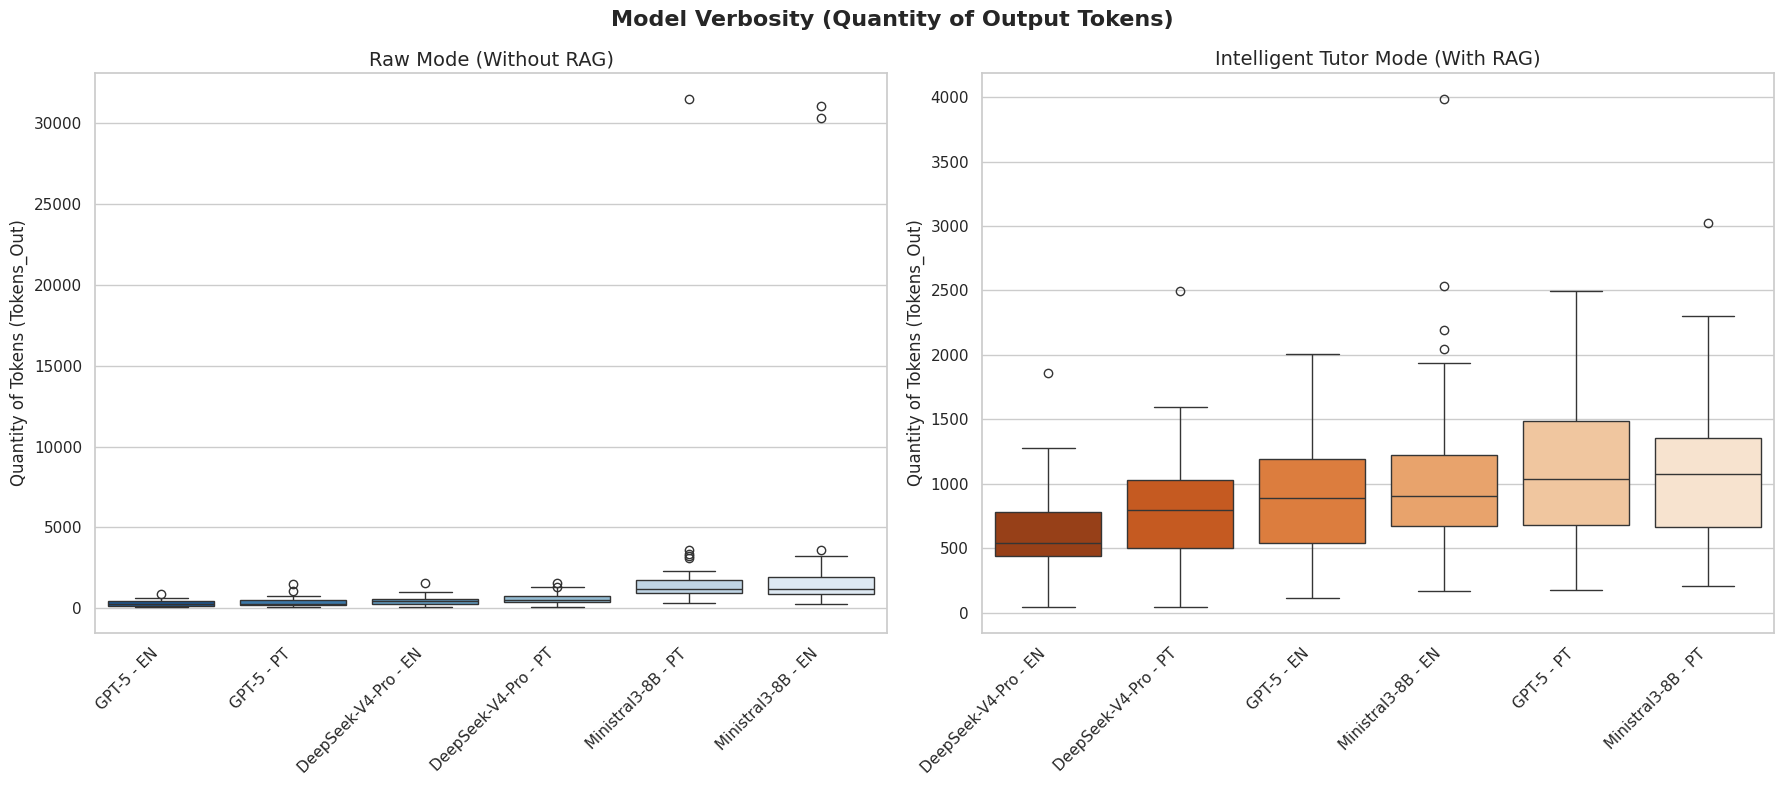

In [9]:
sns.set_theme(style="whitegrid")
# Changed: sharey=False allows each chart to have its own scale
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=False)
fig.suptitle('Model Verbosity (Quantity of Output Tokens)', fontsize=16, fontweight='bold')

# Order Raw
raw_order = df_raw.groupby('Variacao')['Tokens_Out'].median().sort_values().index
sns.boxplot(data=df_raw, x='Variacao', y='Tokens_Out', order=raw_order, ax=axes[0], palette="Blues_r")
axes[0].set_title('Raw Mode (Without RAG)', fontsize=14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_xlabel('')
axes[0].set_ylabel('Quantity of Tokens (Tokens_Out)', fontsize=12)

# Order Tutor
tutor_order = df_tutor.groupby('Variacao')['Tokens_Out'].median().sort_values().index
sns.boxplot(data=df_tutor, x='Variacao', y='Tokens_Out', order=tutor_order, ax=axes[1], palette="Oranges_r")
axes[1].set_title('Intelligent Tutor Mode (With RAG)', fontsize=14)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_xlabel('')
# Changed: Added the Y-axis label back for the Tutor chart
axes[1].set_ylabel('Quantity of Tokens (Tokens_Out)', fontsize=12)

plt.tight_layout()
plt.show()

### **3.4 - Comparison Tests (A vs B)**

To compare the verbosity between the models, the non-parametric **Mann-Whitney U** test was applied. This test is suitable for evaluating whether there is a difference between the medians of two independent groups without assuming data normality.

The hypotheses formulated for the comparison between two models ($M_1$ and $M_2$) follow a **two-sided** approach:

* **Null Hypothesis ($H_0$):** The verbosity medians of the two models are equal.  
  $$H_0: \text{Median}(M_1) = \text{Median}(M_2)$$
* **Alternative Hypothesis ($H_1$):** The verbosity medians of the two models are significantly different.  
  $$H_1: \text{Median}(M_1) \neq \text{Median}(M_2)$$

**Significance and Grouping Criteria:**
* **Configuration:** The `alternative='two-sided'` parameter was used.
* **Significance Level:** $\alpha = 0.10$ was adopted.
* **Interpretation:** If the $p\text{-value} \ge 0.10$, the null hypothesis is not rejected, indicating that there is no statistical evidence to state that one model is more verbose than the other. In these cases, the models are grouped under the same category (e.g., G1, G2), signaling statistical equivalence despite nominal variations in the observations.

In [10]:
# ==========================================================
# 1. STATISTICAL GROUPING FUNCTION (Kept intact and perfect)
# ==========================================================
def calculate_statistical_groups(df_analysis, ordered_variations, alpha=0.10):
    n = len(ordered_variations)
    equivalence_spans = []

    for i in range(n):
        data_i = df_analysis[df_analysis['Label_X'] == ordered_variations[i]]['Tokens_Out'].dropna()
        upper_limit = i
        for j in range(i + 1, n):
            data_j = df_analysis[df_analysis['Label_X'] == ordered_variations[j]]['Tokens_Out'].dropna()
            _, p_val = mannwhitneyu(data_i, data_j, alternative='two-sided')
            if p_val >= alpha:
                upper_limit = j
            else:
                break
        current_span = set(range(i, upper_limit + 1))
        equivalence_spans.append(current_span)

    unique_spans = []
    for s in equivalence_spans:
        is_subset = any(s.issubset(other) and s != other for other in equivalence_spans)
        if not is_subset and s not in unique_spans:
            unique_spans.append(s)

    unique_spans.sort(key=lambda x: min(x))
    final_groups = [[] for _ in range(n)]

    for group_id, span in enumerate(unique_spans):
        group_name = f"G{group_id + 1}"
        for model_idx in span:
            final_groups[model_idx].append(group_name)

    return [", ".join(groups) for groups in final_groups]

In [11]:
# ==========================================================
# 2. VISUAL CODING DICTIONARIES (ACADEMIC AND ELEGANT)
# ==========================================================
# Shape (Marker) -> Defines the Model
model_shapes = {
    'Ministral3-8B': '^',   # Triangle
    'DeepSeek-V4-Pro': 's', # Square
    'GPT-5': 'o'            # Circle
}

# Fill Color (Facecolor) -> Defines RAG vs Without RAG
mode_colors = {
    'Raw': '#F2F3F4',   # Ice / Almost white (Without RAG)
    'Tutor': '#5D6D7E'  # Elegant Slate Gray (With RAG)
}

# Edge Color (Edgecolor) -> Defines the Language
language_colors = {
    'PT': '#000000', # Absolute Black
    'EN': '#B22222'  # Firebrick (Elegant dark red)
}

In [12]:
# ==========================================================
# 3. UNIFIED DATA PREPARATION
# ==========================================================
# Joins the two dataframes into one
df_all = pd.concat([df_raw, df_tutor], ignore_index=True)

# Creates a concise X label to fit the column (E.g.: "GPT-5 (PT)\nWith RAG")
df_all['Label_X'] = df_all['Modelo_Limpo'] + ' (' + df_all['Idioma'] + ')\n' + df_all['Modo']

# Calculates medians and sorts to create the GLOBAL RANKING
df_med = df_all.groupby(['Label_X', 'Modelo_Limpo', 'Idioma', 'Modo'])['Tokens_Out'].median().reset_index()
df_med = df_med.sort_values(by='Tokens_Out').reset_index(drop=True)

# Calculates Statistics and Intervals
df_med['Grupo_Estatistico'] = calculate_statistical_groups(df_all, df_med['Label_X'].tolist())

ci_infs, ci_sups = [], []
for var in df_med['Label_X']:
    data = df_all[df_all['Label_X'] == var]['Tokens_Out'].dropna()
    res_boot = bootstrap((data,), np.median, confidence_level=0.90, method='percentile', random_state=42)
    ci_infs.append(res_boot.confidence_interval.low)
    ci_sups.append(res_boot.confidence_interval.high)

df_med['CI_Inf'] = ci_infs
df_med['CI_Sup'] = ci_sups

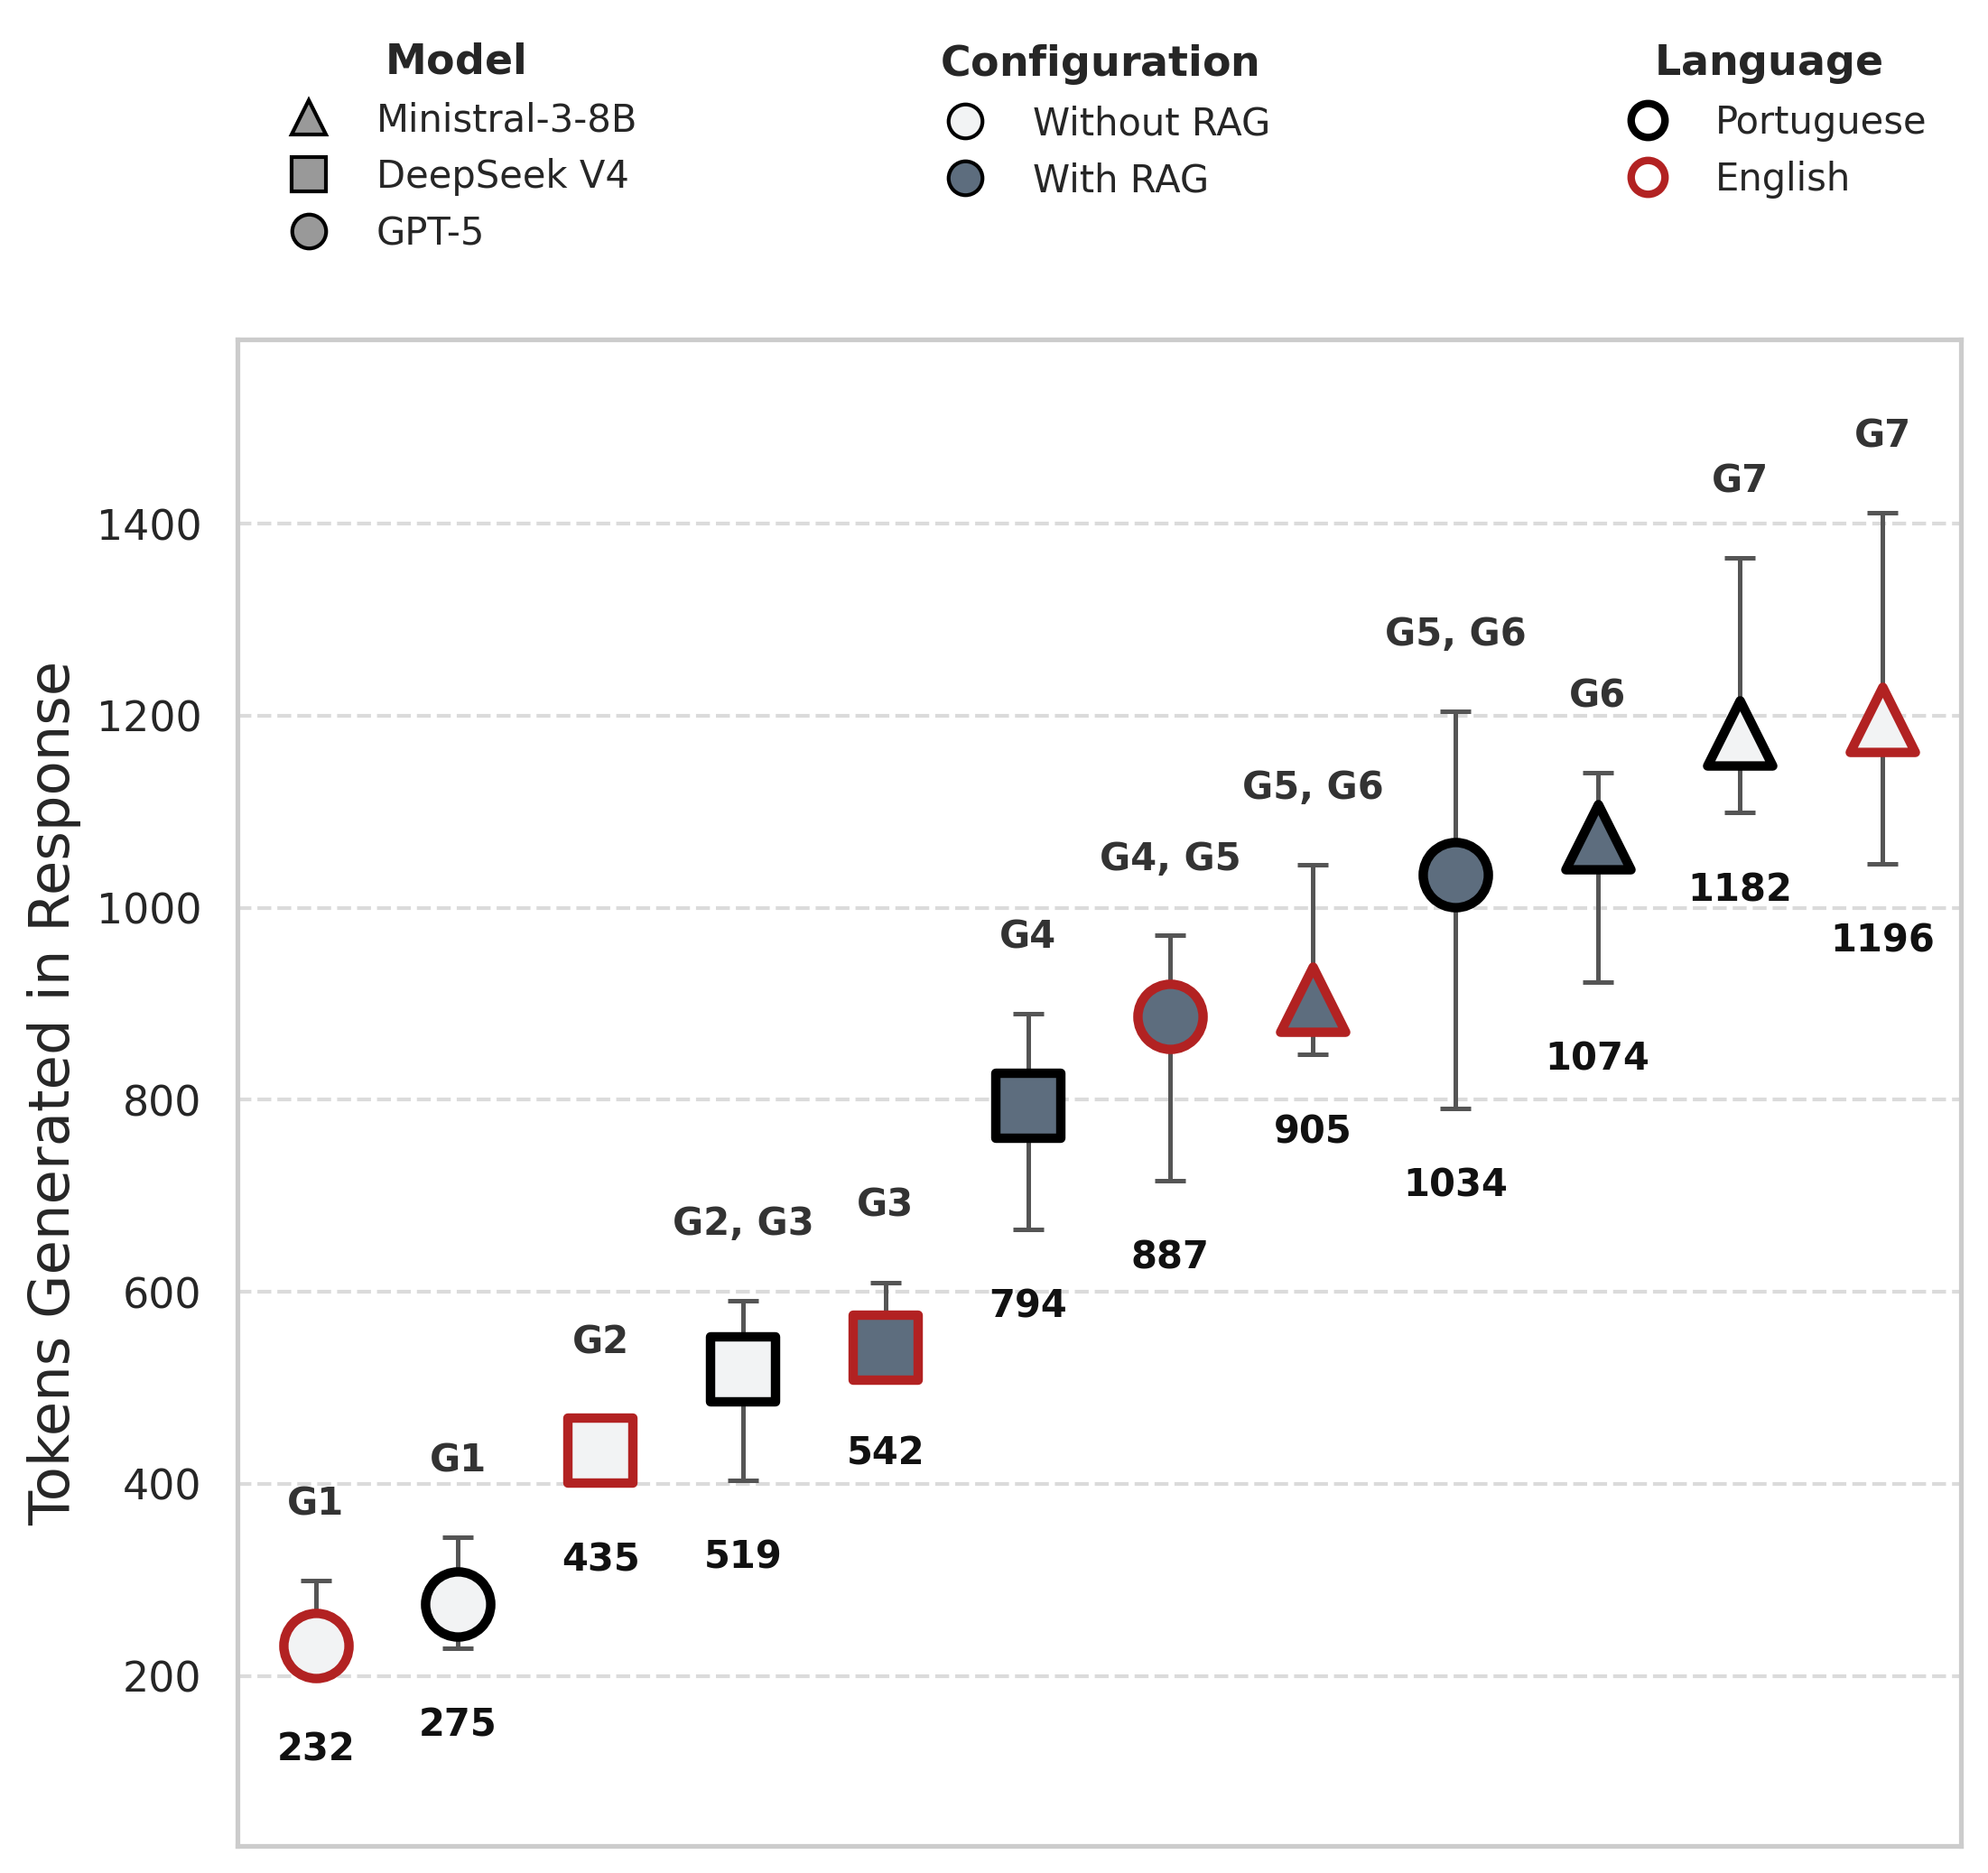

In [15]:
# ==========================================================
# 4. SINGLE CHART PLOTTING (COLUMN FORMAT)
# ==========================================================
sns.set_theme(style="whitegrid")

# The 300 DPI (Dots Per Inch) value is the gold standard for academic publication.
fig, ax = plt.subplots(figsize=(7.5, 7.5), dpi=300)

ax.grid(True, axis='y', linestyle='--', alpha=0.7)
range_y = df_med['CI_Sup'].max() - df_med['CI_Inf'].min()
offset_text = range_y * 0.05

for i, row in df_med.iterrows():
    # Error Bar (Confidence Interval)
    ax.errorbar(
        x=row['Label_X'], y=row['Tokens_Out'],
        yerr=[[row['Tokens_Out'] - row['CI_Inf']], [row['CI_Sup'] - row['Tokens_Out']]],
        fmt='none', ecolor='#555555', capsize=4, capthick=1.2, linewidth=1.2, zorder=2
    )

    # Multidimensional Marker
    ax.scatter(
        row['Label_X'], row['Tokens_Out'],
        s=300,
        marker=model_shapes[row['Modelo_Limpo']],
        facecolors=mode_colors[row['Modo']],
        edgecolors=language_colors[row['Idioma']],
        linewidths=2.5, zorder=3
    )

    # Groups Text (Above)
    ax.text(
        row['Label_X'], row['CI_Sup'] + offset_text, row['Grupo_Estatistico'],
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333'
    )

    # ADJUSTMENT: Median numbers as integers, darker and bold
    ax.text(
        row['Label_X'], row['CI_Inf'] - offset_text, f"{int(row['Tokens_Out'])}",
        ha='center', va='top', fontsize=10, fontweight='bold', color='#111111'
    )

# Title and Axes Formatting
#ax.set_title("Global Verbosity Ranking", fontsize=14, pad=15, fontweight='bold')

# ADJUSTMENT 1: We completely removed the X axis (ticks and labels)
ax.set_xticks([])
ax.set_xticklabels([])
ax.set_xlabel('')

ax.set_ylabel('Tokens Generated in Response', fontsize=15)
ax.set_ylim(df_med['CI_Inf'].min() - (range_y * 0.15), df_med['CI_Sup'].max() + (range_y * 0.15))

# ==========================================================
# 5. MULTIDIMENSIONAL LEGENDS (TOP-ALIGNED)
# ==========================================================

# 5.1 Groups Definition (Kept)
leg_model = [
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#999999', markeredgecolor='black', markersize=9, label='Ministral-3-8B'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#999999', markeredgecolor='black', markersize=9, label='DeepSeek V4'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#999999', markeredgecolor='black', markersize=9, label='GPT-5')
]

leg_config = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=mode_colors['Raw'], markeredgecolor='black', markersize=9, label='Without RAG'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=mode_colors['Tutor'], markeredgecolor='black', markersize=9, label='With RAG')
]

leg_lang = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor=language_colors['PT'], markeredgewidth=2, markersize=9, label='Portuguese'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor=language_colors['EN'], markeredgewidth=2, markersize=9, label='English')
]

# 5.2 Adding top-aligned legends
y_pos = 1.22

L1 = ax.legend(handles=leg_model, title=r'$\mathbf{Model}$', loc='upper left',
               bbox_to_anchor=(0.0, y_pos), ncol=1, fontsize=10, frameon=False, title_fontsize=11)
ax.add_artist(L1)

L2 = ax.legend(handles=leg_config, title=r'$\mathbf{Configuration}$', loc='upper center',
               bbox_to_anchor=(0.5, y_pos), ncol=1, fontsize=10, frameon=False, title_fontsize=11)
ax.add_artist(L2)

L3 = ax.legend(handles=leg_lang, title=r'$\mathbf{Language}$', loc='upper right',
               bbox_to_anchor=(1.0, y_pos), ncol=1, fontsize=10, frameon=False, title_fontsize=11)

# 5.3 Final Layout and Export Adjustments
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('image_2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('image_2.pdf', format='pdf', bbox_inches='tight')

plt.show()

### **3.5 - Statistical Details (Confidence Intervals and Pairwise Tests)**

In [16]:
print("="*80)
print("TABLE 3: Verbosity Ranking with Confidence Intervals (90%)")
print("="*80)

# Selecting relevant columns for the report
detailed_table = df_med[[
    'Label_X', 'Tokens_Out', 'CI_Inf', 'CI_Sup', 'Grupo_Estatistico'
]].copy()

detailed_table.columns = ['Configuration (Model/Language/Mode)', 'Median', 'CI_90%_Lower', 'CI_90%_Upper', 'Group']
display(detailed_table.round(1))

TABLE 3: Verbosity Ranking with Confidence Intervals (90%)


,Configuration (Model/Language/Mode),Median,CI_90%_Lower,CI_90%_Upper,Group
0,GPT-5 (EN)\nRaw,232.0,204.0,299.0,G1
1,GPT-5 (PT)\nRaw,275.0,229.0,344.0,G1
2,DeepSeek-V4-Pro (EN)\nRaw,435.0,401.0,467.0,G2
3,DeepSeek-V4-Pro (PT)\nRaw,519.0,404.0,591.0,"G2, G3"
4,DeepSeek-V4-Pro (EN)\nTutor,542.0,512.0,610.0,G3
5,DeepSeek-V4-Pro (PT)\nTutor,794.0,665.0,890.0,G4
6,GPT-5 (EN)\nTutor,887.0,716.0,971.0,"G4, G5"
7,Ministral3-8B (EN)\nTutor,905.0,847.0,1045.0,"G5, G6"
8,GPT-5 (PT)\nTutor,1034.0,791.0,1205.0,"G5, G6"
9,Ministral3-8B (PT)\nTutor,1074.0,923.0,1141.0,G6


In [17]:
def perform_ranking_tests(df_analysis, order, alpha=0.10):
    """
    Mann-Whitney tests with intelligent pruning.
    For each i, tests with sequential j until the first significant one is found.
    """
    results = []
    n = len(order)

    print(f"\n Mann-Whitney Tests with Pruning (α = {alpha})")
    #print(f"Ordering: {order[0].replace('|', ' - ')} (largest) → ... → {order[-1].replace('|', ' - ')} (smallest)")
    print("-" * 80)

    for i in range(n - 1):
        g1 = order[i]
        d1 = df_analysis[df_analysis['Label_X'] == g1]['Tokens_Out'].dropna()

        found_difference = False

        for j in range(i + 1, n):
            g2 = order[j]
            d2 = df_analysis[df_analysis['Label_X'] == g2]['Tokens_Out'].dropna()

            # Two-sided test
            stat, p_val = mannwhitneyu(d1, d2, alternative='two-sided')

            results.append({
                "Comparison": f"{g1.replace('|', ' - ')} vs {g2.replace('|', ' - ')}",
                "p-value": round(p_val, 6),
                f"Significant (α={alpha})": " DIFFERENT" if p_val < alpha else " EQUIVALENT"
            })

            # If a significant difference is found, stop testing the next ones
            if p_val < alpha:
                found_difference = True
                break

        # Optional debug
        #if found_difference:
        #    print(f"  {g1.replace('|', ' - ')}: stopped when finding difference")

    return pd.DataFrame(results)

In [18]:
# Make sure the order is correct (smallest to largest)
df_median = df_all.groupby('Label_X')['Tokens_Out'].median().sort_values(ascending=True).reset_index()
ranking_order = df_median['Label_X'].tolist()

# Calculate statistical equivalence groups
groups = calculate_statistical_groups(df_all, ranking_order, alpha=0.10)

# Show complete table of pairwise comparisons
df_pairwise = perform_ranking_tests(df_all, ranking_order, alpha=0.10)
print("\n" + "="*80)
print("TABLE 4: Test Results")
print("="*80)
display(df_pairwise)


 Mann-Whitney Tests with Pruning (α = 0.1)
--------------------------------------------------------------------------------

TABLE 4: Test Results


,Comparison,p-value,Significant (α=0.1)
0,GPT-5 (EN)\nRaw vs GPT-5 (PT)\nRaw,0.207860,EQUIVALENT
1,GPT-5 (EN)\nRaw vs DeepSeek-V4-Pro (EN)\nRaw,0.000057,DIFFERENT
2,GPT-5 (PT)\nRaw vs DeepSeek-V4-Pro (EN)\nRaw,0.005391,DIFFERENT
3,DeepSeek-V4-Pro (EN)\nRaw vs DeepSeek-V4-Pro (...,0.212761,EQUIVALENT
4,DeepSeek-V4-Pro (EN)\nRaw vs DeepSeek-V4-Pro (...,0.004878,DIFFERENT
5,DeepSeek-V4-Pro (PT)\nRaw vs DeepSeek-V4-Pro (...,0.264068,EQUIVALENT
6,DeepSeek-V4-Pro (PT)\nRaw vs DeepSeek-V4-Pro (...,0.000683,DIFFERENT
7,DeepSeek-V4-Pro (EN)\nTutor vs DeepSeek-V4-Pro...,0.012322,DIFFERENT
8,DeepSeek-V4-Pro (PT)\nTutor vs GPT-5 (EN)\nTutor,0.198310,EQUIVALENT
9,DeepSeek-V4-Pro (PT)\nTutor vs Ministral3-8B (...,0.038753,DIFFERENT


The evaluation of the median quantity of generated *tokens* (verbosity) reveals statistically distinct behaviors among the models when subjected to the Raw Mode (free parametric knowledge) and the Intelligent Tutor Mode (RAG architecture with context restriction). From the grouping generated by the Mann-Whitney test ($\alpha = 0.10$), the following findings stand out:

**1. The RAG Effect (Expansion vs. Contraction)**

* Contrary to the hypothesis that the RAG system would cause "universal conciseness", the data shows that the effect of the context depends on the model's baseline behavior.
* For naturally concise models, such as GPT-5 and DeepSeek, the Tutor Mode **drastically increased** verbosity (e.g., GPT-5 jumped from ~250 *tokens* in the raw mode to ~950 in the Tutor mode). On the other hand, for the naturally verbose model (Ministral-3-8B), RAG acted as a limiter, reducing the median from ~1,190 to the ~990 *tokens* range.
* This indicates that the retrieved text *chunks* act as a "size anchor": they force concise models to elaborate more to explain the context, while curbing the deductive hallucinations of the more verbose models.

**2. Raw Mode: The True Natural Hierarchy**

* Without the restrictions of RAG, verbosity reflects the default alignment of each architecture, dividing the models into well-defined opposite extremes:
* **Group 1 (Greatest Conciseness):** GPT-5 (medians between 232 and 275 *tokens*). The model demonstrates a strong preference for direct answers when there is no context to be dissected.
* **Groups 2 and 3 (Intermediate):** DeepSeek V4 Pro (medians between 435 and 519 *tokens*).
* **Group 7 (Greatest Verbosity):** Ministral-3-8B (medians between 1,182 and 1,196 *tokens*), generating almost five times more text than GPT-5 for the same requests.

* Language (PT vs. EN) caused fluctuations within the same model (generally requiring more *tokens* in Portuguese), but these variations were not sufficient to break the global hierarchy of the architectures in the raw mode.

**3. Tutor Mode: The Contextual Reconfiguration**

* The introduction of the Intelligent Tutor *prompt* completely reconfigured the statistical positions:
* **DeepSeek's Efficiency:** In the RAG environment, DeepSeek V4 Pro became the **most concise** model among the tutors (Groups 3 and 4, with 542 to 794 *tokens*). This suggests strict alignment with the synthesis guidelines of the *System Prompt*.
* **Leveling at the Top (Convergence):** GPT-5 and Ministral-3-8B, which were the absolute extremes in the raw mode, were statistically brought closer by the RAG architecture. Both converged to the high verbosity groups (**G4 to G6**), transitioning into the range of 880 to 1,070 *tokens*. The statistical test confirmed, for example, that there is no significant difference between GPT-5 (EN) Tutor and Ministral (EN) Tutor ($p = 0.343$).

## **4 - Analysis of the Tokens Per Second (TPS) Variable**

### **4.1 - Summary Table (Descriptive Statistics)**

In [19]:
df_total = pd.concat([df_raw, df_tutor], ignore_index=True)

summary_table = df_total.groupby(['Modo', 'Variacao'])['Throughput_tps'].agg(
    Mean='mean',
    Median='median',
    Standard_Deviation='std',
    Minimum='min',
    Maximum='max'
).round(2).reset_index()

In [20]:
print("="*60)
print("TABLE 5: Tokens per Second (TPS)")
print("="*60)
display(summary_table) # Shows the beautiful table in Jupyter for your advisor

TABLE 5: Tokens per Second (TPS)


,Modo,Variacao,Mean,Median,Standard_Deviation,Minimum,Maximum
0,Raw,DeepSeek-V4-Pro - EN,70.79,73.09,11.02,38.73,91.41
1,Raw,DeepSeek-V4-Pro - PT,68.10,67.26,10.03,40.25,85.73
2,Raw,GPT-5 - EN,117.78,120.17,41.29,43.53,335.20
3,Raw,GPT-5 - PT,101.25,106.51,31.40,24.94,168.02
4,Raw,Ministral3-8B - EN,70.26,70.65,4.03,57.72,78.67
5,Raw,Ministral3-8B - PT,72.40,72.62,4.34,60.04,82.16
6,Tutor,DeepSeek-V4-Pro - EN,64.61,64.37,9.68,45.74,102.48
7,Tutor,DeepSeek-V4-Pro - PT,53.70,53.02,7.22,32.15,69.58
8,Tutor,GPT-5 - EN,92.01,94.46,28.56,28.53,162.04
9,Tutor,GPT-5 - PT,117.30,113.86,28.10,42.08,195.55


### **4.2 - Normality Analysis (Shapiro-Wilk)**

In [21]:
print("\n" + "="*60)
print("TABLE 6: Shapiro-Wilk Normality Test (Alpha = 0.10)")
print("="*60)

normal_groups = True

for mode, df_mode in [("Raw", df_raw), ("Tutor", df_tutor)]:
    for variation in df_mode['Variacao'].unique():
        data = df_mode[df_mode['Variacao'] == variation]['Throughput_tps'].dropna()
        stat, p_value = shapiro(data)

        is_normal = p_value > 0.10
        if not is_normal:
            normal_groups = False

        status = "NORMAL" if is_normal else "NOT NORMAL"
        print(f"[{mode}] {variation:^30} | p-value: {p_value:.4f} -> {status}")

print("\nNormality Conclusion:")
if normal_groups:
    print("All groups follow a normal distribution. We will use the T-TEST for comparison.")
else:
    print("At least one group violated normality. We will use the MANN-WHITNEY TEST.")


TABLE 6: Shapiro-Wilk Normality Test (Alpha = 0.10)
[Raw]       Ministral3-8B - PT       | p-value: 0.0705 -> NOT NORMAL
[Raw]       Ministral3-8B - EN       | p-value: 0.0185 -> NOT NORMAL
[Raw]      DeepSeek-V4-Pro - PT      | p-value: 0.1419 -> NORMAL
[Raw]      DeepSeek-V4-Pro - EN      | p-value: 0.0262 -> NOT NORMAL
[Raw]           GPT-5 - PT           | p-value: 0.2401 -> NORMAL
[Raw]           GPT-5 - EN           | p-value: 0.0000 -> NOT NORMAL
[Tutor]       Ministral3-8B - PT       | p-value: 0.0038 -> NOT NORMAL
[Tutor]       Ministral3-8B - EN       | p-value: 0.3185 -> NORMAL
[Tutor]      DeepSeek-V4-Pro - PT      | p-value: 0.5922 -> NORMAL
[Tutor]      DeepSeek-V4-Pro - EN      | p-value: 0.0154 -> NOT NORMAL
[Tutor]           GPT-5 - PT           | p-value: 0.1037 -> NORMAL
[Tutor]           GPT-5 - EN           | p-value: 0.1115 -> NORMAL

Normality Conclusion:
At least one group violated normality. We will use the MANN-WHITNEY TEST.


### **4.3. Graphical Analysis**

/tmp/ipykernel_32080/45318281.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='Variacao', y='Throughput_tps', order=raw_order, ax=axes[0], palette="Blues_r")
/tmp/ipykernel_32080/45318281.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_32080/45318281.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tutor, x='Variacao', y='Throughput_tps', order=tutor_order, ax=axes[1], palette="Oranges_r")
/tmp/ipykernel_32080/45318281.py:18: UserWarning: set_ticklabels() should only be used with a 

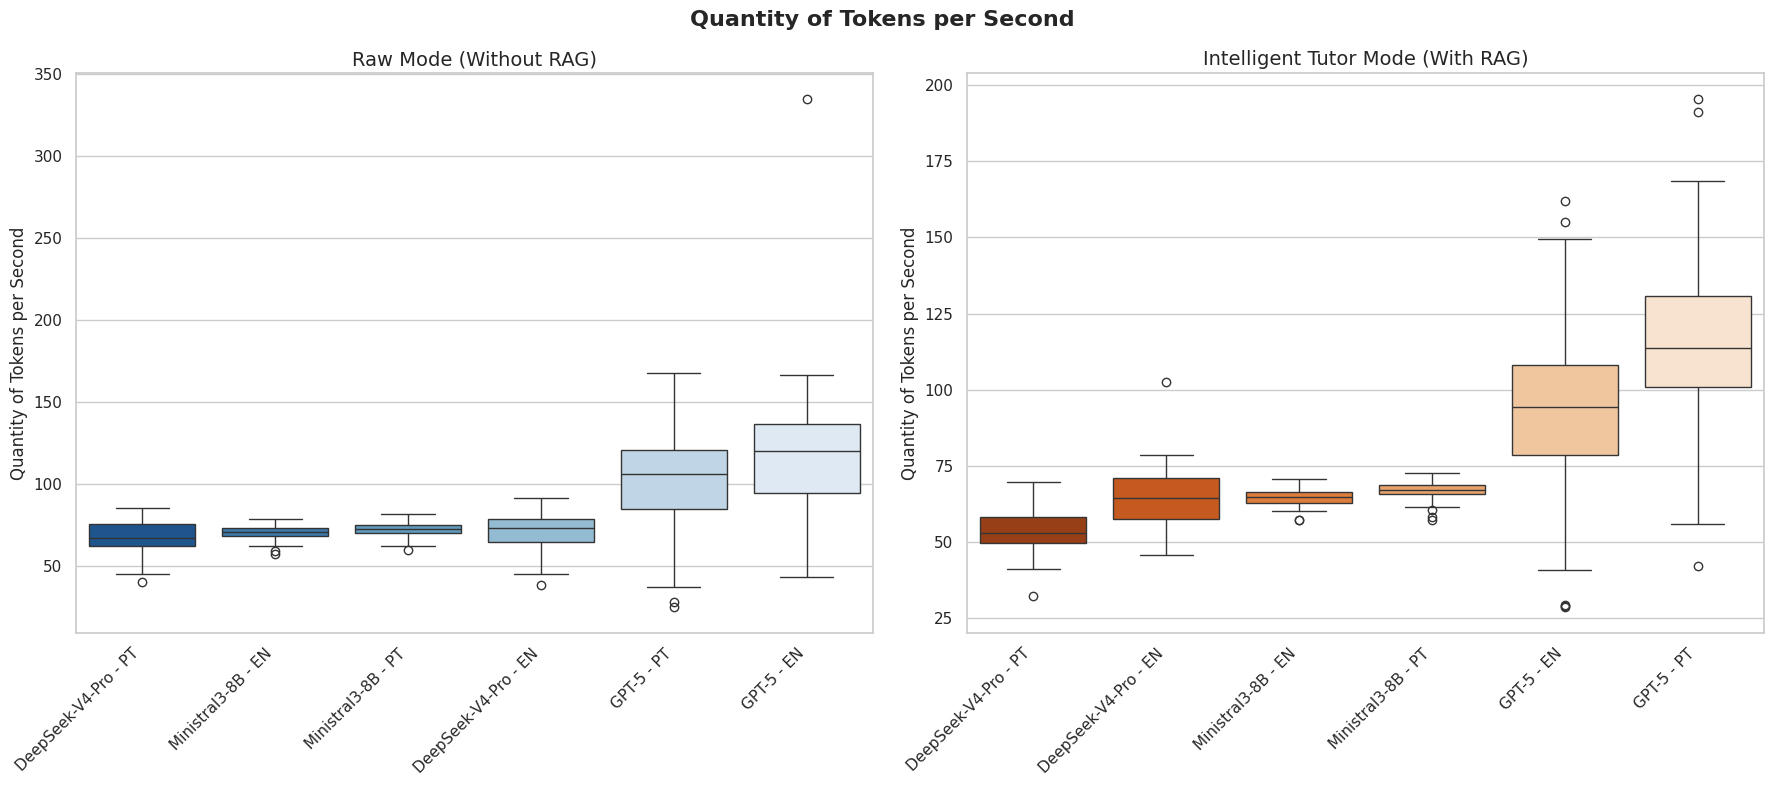

In [22]:
sns.set_theme(style="whitegrid")
# Changed: sharey=False allows each chart to have its own scale
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=False)
fig.suptitle('Quantity of Tokens per Second', fontsize=16, fontweight='bold')

# Order Raw
raw_order = df_raw.groupby('Variacao')['Throughput_tps'].median().sort_values().index
sns.boxplot(data=df_raw, x='Variacao', y='Throughput_tps', order=raw_order, ax=axes[0], palette="Blues_r")
axes[0].set_title('Raw Mode (Without RAG)', fontsize=14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_xlabel('')
axes[0].set_ylabel('Quantity of Tokens per Second', fontsize=12)

# Order Tutor
tutor_order = df_tutor.groupby('Variacao')['Throughput_tps'].median().sort_values().index
sns.boxplot(data=df_tutor, x='Variacao', y='Throughput_tps', order=tutor_order, ax=axes[1], palette="Oranges_r")
axes[1].set_title('Intelligent Tutor Mode (With RAG)', fontsize=14)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_xlabel('')
# Changed: Added the Y-axis label back for the Tutor chart
axes[1].set_ylabel('Quantity of Tokens per Second', fontsize=12)

plt.tight_layout()
plt.show()

### **4.4 - Comparison Tests (A vs B)**

To compare the generation speed — measured in *Tokens* per Second (TPS) — between the models, the non-parametric **Mann-Whitney U** test was applied. This test is suitable for evaluating whether there is a difference between the medians of two independent groups without assuming data normality.

The hypotheses formulated for the comparison between two models ($M_1$ and $M_2$) follow a **two-sided** approach:

* **Null Hypothesis ($H_0$):** The TPS medians of the two models are equal.  
  $$H_0: \text{Median}(M_1) = \text{Median}(M_2)$$
* **Alternative Hypothesis ($H_1$):** The TPS medians of the two models are significantly different.  
  $$H_1: \text{Median}(M_1) \neq \text{Median}(M_2)$$

**Significance and Grouping Criteria:**
* **Configuration:** The `alternative='two-sided'` parameter was used.
* **Significance Level:** $\alpha = 0.10$ was adopted.
* **Interpretation:** If the $p\text{-value} \ge 0.10$, the null hypothesis is not rejected, indicating that there is no statistical evidence to state that one model is faster (higher TPS) than the other. In these cases, the models are grouped under the same category (e.g., G1, G2), signaling statistical equivalence in inference speed, despite nominal variations in the observations.

In [23]:
# ==========================================================
# 1. STATISTICAL GROUPING FUNCTION (Kept intact and perfect)
# ==========================================================
def calculate_statistical_groups(df_analysis, ordered_variations, alpha=0.10):
    n = len(ordered_variations)
    equivalence_spans = []

    for i in range(n):
        data_i = df_analysis[df_analysis['Label_X'] == ordered_variations[i]]['Throughput_tps'].dropna()
        upper_limit = i
        for j in range(i + 1, n):
            data_j = df_analysis[df_analysis['Label_X'] == ordered_variations[j]]['Throughput_tps'].dropna()
            _, p_val = mannwhitneyu(data_i, data_j, alternative='two-sided')
            if p_val >= alpha:
                upper_limit = j
            else:
                break
        current_span = set(range(i, upper_limit + 1))
        equivalence_spans.append(current_span)

    unique_spans = []
    for s in equivalence_spans:
        is_subset = any(s.issubset(other) and s != other for other in equivalence_spans)
        if not is_subset and s not in unique_spans:
            unique_spans.append(s)

    unique_spans.sort(key=lambda x: min(x))
    final_groups = [[] for _ in range(n)]

    for group_id, span in enumerate(unique_spans):
        group_name = f"G{group_id + 1}"
        for model_idx in span:
            final_groups[model_idx].append(group_name)

    return [", ".join(groups) for groups in final_groups]

In [24]:
# ==========================================================
# 2. VISUAL CODING DICTIONARIES (ACADEMIC AND ELEGANT)
# ==========================================================
# Shape (Marker) -> Defines the Model
model_shapes = {
    'Ministral3-8B': '^',   # Triangle
    'DeepSeek-V4-Pro': 's', # Square
    'GPT-5': 'o'            # Circle
}

# Fill Color (Facecolor) -> Defines RAG vs Without RAG
mode_colors = {
    'Raw': '#F2F3F4',   # Ice / Almost white (Without RAG)
    'Tutor': '#5D6D7E'  # Elegant Slate Gray (With RAG)
}

# Edge Color (Edgecolor) -> Defines the Language
language_colors = {
    'PT': '#000000', # Absolute Black
    'EN': '#B22222'  # Firebrick (Elegant dark red)
}

In [25]:
# ==========================================================
# 3. UNIFIED DATA PREPARATION
# ==========================================================
# Joins the two dataframes into one
df_all = pd.concat([df_raw, df_tutor], ignore_index=True)

# Creates a concise X label to fit the column (E.g.: "GPT-5 (PT)\nWith RAG")
df_all['Label_X'] = df_all['Modelo_Limpo'] + ' (' + df_all['Idioma'] + ')\n' + df_all['Modo']

# Calculates medians and sorts to create the GLOBAL RANKING
df_med = df_all.groupby(['Label_X', 'Modelo_Limpo', 'Idioma', 'Modo'])['Throughput_tps'].median().reset_index()
df_med = df_med.sort_values(by='Throughput_tps').reset_index(drop=True)

# Calculates Statistics and Intervals
df_med['Grupo_Estatistico'] = calculate_statistical_groups(df_all, df_med['Label_X'].tolist())

ci_infs, ci_sups = [], []
for var in df_med['Label_X']:
    data = df_all[df_all['Label_X'] == var]['Throughput_tps'].dropna()
    res_boot = bootstrap((data,), np.median, confidence_level=0.90, method='percentile', random_state=42)
    ci_infs.append(res_boot.confidence_interval.low)
    ci_sups.append(res_boot.confidence_interval.high)

df_med['CI_Inf'] = ci_infs
df_med['CI_Sup'] = ci_sups

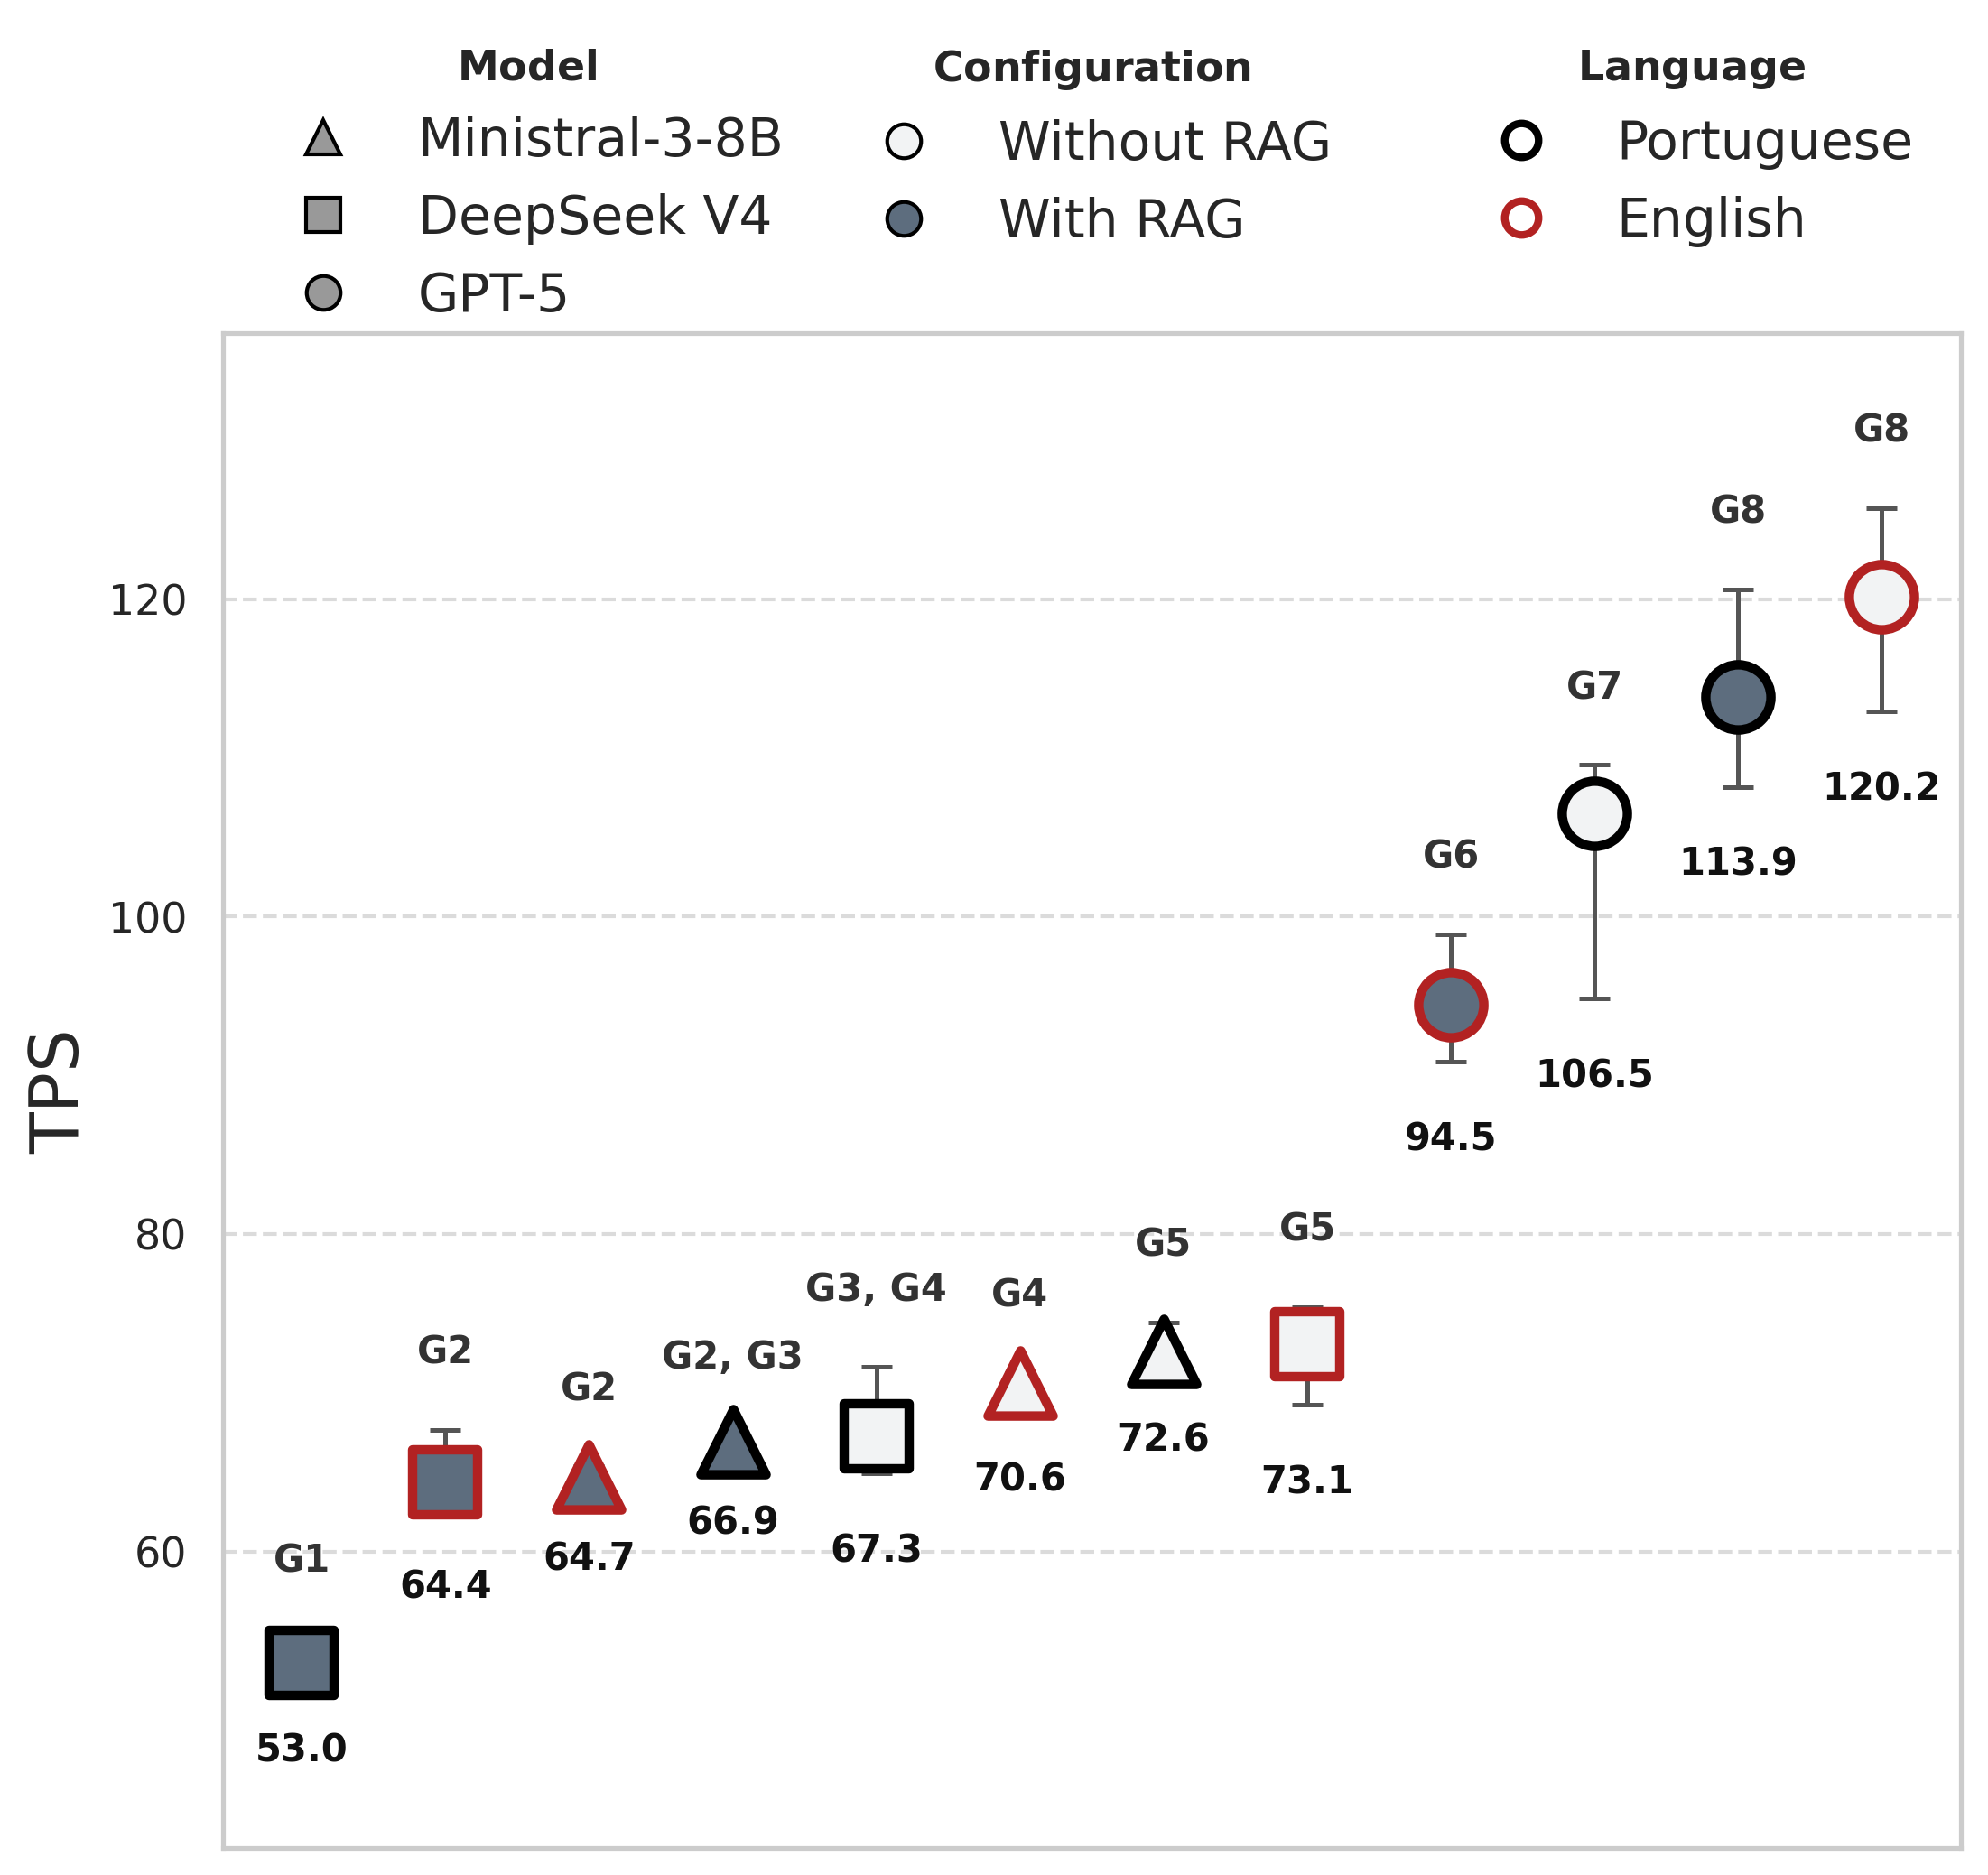

In [26]:
# ==========================================================
# 4. SINGLE CHART PLOTTING (COLUMN FORMAT)
# ==========================================================
sns.set_theme(style="whitegrid")

# The 300 DPI (Dots Per Inch) value is the gold standard for academic publication.
fig, ax = plt.subplots(figsize=(7.5, 7.5), dpi=300)

ax.grid(True, axis='y', linestyle='--', alpha=0.7)
range_y = df_med['CI_Sup'].max() - df_med['CI_Inf'].min()
offset_text = range_y * 0.05

for i, row in df_med.iterrows():
    # Error Bar (Confidence Interval)
    ax.errorbar(
        x=row['Label_X'], y=row['Throughput_tps'],
        yerr=[[row['Throughput_tps'] - row['CI_Inf']], [row['CI_Sup'] - row['Throughput_tps']]],
        fmt='none', ecolor='#555555', capsize=4, capthick=1.2, linewidth=1.2, zorder=2
    )

    # Multidimensional Marker
    ax.scatter(
        row['Label_X'], row['Throughput_tps'],
        s=300,
        marker=model_shapes[row['Modelo_Limpo']],
        facecolors=mode_colors[row['Modo']],
        edgecolors=language_colors[row['Idioma']],
        linewidths=2.5, zorder=3
    )

    # Groups Text (Above)
    ax.text(
        row['Label_X'], row['CI_Sup'] + offset_text, row['Grupo_Estatistico'],
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333'
    )

    # ADJUSTMENT 3: Darker median numbers (color='#111111') and in bold (fontweight='bold')
    ax.text(
        row['Label_X'], row['CI_Inf'] - offset_text, f"{row['Throughput_tps']:.1f}",
        ha='center', va='top', fontsize=10, fontweight='bold', color='#111111'
    )

# Title and Axes Formatting
#ax.set_title("Global Verbosity Ranking", fontsize=14, pad=15, fontweight='bold')

# ADJUSTMENT 1: We completely removed the X axis (ticks and labels)
ax.set_xticks([])
ax.set_xticklabels([])
ax.set_xlabel('')

ax.set_ylabel('TPS', fontsize=18)
ax.set_ylim(df_med['CI_Inf'].min() - (range_y * 0.15), df_med['CI_Sup'].max() + (range_y * 0.15))

# ==========================================================
# 5. MULTIDIMENSIONAL LEGENDS (TOP-ALIGNED)
# ==========================================================

# 5.1 Groups Definition (Kept)
leg_model = [
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#999999', markeredgecolor='black', markersize=9, label='Ministral-3-8B'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#999999', markeredgecolor='black', markersize=9, label='DeepSeek V4'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#999999', markeredgecolor='black', markersize=9, label='GPT-5')
]

leg_config = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=mode_colors['Raw'], markeredgecolor='black', markersize=9, label='Without RAG'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=mode_colors['Tutor'], markeredgecolor='black', markersize=9, label='With RAG')
]

leg_lang = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor=language_colors['PT'], markeredgewidth=2, markersize=9, label='Portuguese'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor=language_colors['EN'], markeredgewidth=2, markersize=9, label='English')
]

# 5.2 Adding top-aligned legends (upper)
# The Y coordinate of bbox_to_anchor (1.18) defines the height.
# If it still cuts off, increase to 1.20 and decrease the 0.82 value in the tight_layout rect.

y_pos = 1.22 # Common height for titles

L1 = ax.legend(handles=leg_model, title=r'$\mathbf{Model}$', loc='upper left',
               bbox_to_anchor=(0.0, y_pos), ncol=1, fontsize=14, frameon=False, title_fontsize=11)
ax.add_artist(L1)

L2 = ax.legend(handles=leg_config, title=r'$\mathbf{Configuration}$', loc='upper center',
               bbox_to_anchor=(0.5, y_pos), ncol=1, fontsize=14, frameon=False, title_fontsize=11)
ax.add_artist(L2)

L3 = ax.legend(handles=leg_lang, title=r'$\mathbf{Language}$', loc='upper right',
               bbox_to_anchor=(1.0, y_pos), ncol=1, fontsize=14, frameon=False, title_fontsize=11)

# 5.3 Final Layout and Export Adjustments
# The 0.80 value reserves 20% of the top for the legends, avoiding cutoffs.
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('image_3.png', dpi=300, bbox_inches='tight', facecolor='white')
# In the final saving part, you are already doing it right by using .pdf:
plt.savefig('image_3.pdf', format='pdf', bbox_inches='tight')

plt.show()

### **4.5 - Statistical Details (Confidence Intervals and Pairwise Tests)**

In [27]:
print("="*80)
print("TABLE 7: Throughput Ranking (Tokens per Second) with Confidence Interval (90%)")
print("="*80)

# Selecting relevant columns for the report
detailed_table = df_med[[
    'Label_X', 'Throughput_tps', 'CI_Inf', 'CI_Sup', 'Grupo_Estatistico'
]].copy()

detailed_table.columns = ['Configuration (Model/Language/Mode)', 'Median', 'CI_90%_Lower', 'CI_90%_Upper', 'Group']
display(detailed_table.round(1))

TABLE 7: Throughput Ranking (Tokens per Second) with Confidence Interval (90%)


,Configuration (Model/Language/Mode),Median,CI_90%_Lower,CI_90%_Upper,Group
0,DeepSeek-V4-Pro (PT)\nTutor,53.0,52.3,54.5,G1
1,DeepSeek-V4-Pro (EN)\nTutor,64.4,62.6,67.7,G2
2,Ministral3-8B (EN)\nTutor,64.7,64.4,65.4,G2
3,Ministral3-8B (PT)\nTutor,66.9,66.6,67.4,"G2, G3"
4,DeepSeek-V4-Pro (PT)\nRaw,67.3,64.9,71.6,"G3, G4"
5,Ministral3-8B (EN)\nRaw,70.6,69.4,71.3,G4
6,Ministral3-8B (PT)\nRaw,72.6,71.9,74.4,G5
7,DeepSeek-V4-Pro (EN)\nRaw,73.1,69.2,75.4,G5
8,GPT-5 (EN)\nTutor,94.5,90.8,98.9,G6
9,GPT-5 (PT)\nRaw,106.5,94.8,109.6,G7


In [28]:
def perform_ranking_tests(df_analysis, order, alpha=0.10):
    """
    Mann-Whitney tests with intelligent pruning.
    For each i, tests with sequential j until the first significant one is found.
    """
    results = []
    n = len(order)

    print(f"\n Mann-Whitney Tests with Pruning (α = {alpha})")
    #print(f"Ordering: {order[0].replace('|', ' - ')} (largest) → ... → {order[-1].replace('|', ' - ')} (smallest)")
    print("-" * 80)

    for i in range(n - 1):
        g1 = order[i]
        d1 = df_analysis[df_analysis['Label_X'] == g1]['Throughput_tps'].dropna()

        found_difference = False

        for j in range(i + 1, n):
            g2 = order[j]
            d2 = df_analysis[df_analysis['Label_X'] == g2]['Throughput_tps'].dropna()

            # Two-sided test
            stat, p_val = mannwhitneyu(d1, d2, alternative='two-sided')

            results.append({
                "Comparison": f"{g1.replace('|', ' - ')} vs {g2.replace('|', ' - ')}",
                "p-value": round(p_val, 6),
                f"Significant (α={alpha})": " DIFFERENT" if p_val < alpha else " EQUIVALENT"
            })

            # If a significant difference is found, stop testing the next ones
            if p_val < alpha:
                found_difference = True
                break

        # Optional debug
        #if found_difference:
        #    print(f"  {g1.replace('|', ' - ')}: stopped when finding difference")

    return pd.DataFrame(results)

In [29]:
# Make sure the order is correct (smallest to largest)
df_median = df_all.groupby('Label_X')['Throughput_tps'].median().sort_values(ascending=True).reset_index()
ranking_order = df_median['Label_X'].tolist()

# Calculate statistical equivalence groups
groups = calculate_statistical_groups(df_all, ranking_order, alpha=0.10)

# Show complete table of pairwise comparisons
df_pairwise = perform_ranking_tests(df_all, ranking_order, alpha=0.10)
print("\n" + "="*80)
print("TABLE 8: Test Results")
print("="*80)
display(df_pairwise)


 Mann-Whitney Tests with Pruning (α = 0.1)
--------------------------------------------------------------------------------

TABLE 8: Test Results


,Comparison,p-value,Significant (α=0.1)
0,DeepSeek-V4-Pro (PT)\nTutor vs DeepSeek-V4-Pro...,0.000000,DIFFERENT
1,DeepSeek-V4-Pro (EN)\nTutor vs Ministral3-8B (...,0.987117,EQUIVALENT
2,DeepSeek-V4-Pro (EN)\nTutor vs Ministral3-8B (...,0.102927,EQUIVALENT
3,DeepSeek-V4-Pro (EN)\nTutor vs DeepSeek-V4-Pro...,0.020944,DIFFERENT
4,Ministral3-8B (EN)\nTutor vs Ministral3-8B (PT...,0.000009,DIFFERENT
5,Ministral3-8B (PT)\nTutor vs DeepSeek-V4-Pro (...,0.504516,EQUIVALENT
6,Ministral3-8B (PT)\nTutor vs Ministral3-8B (EN...,0.000000,DIFFERENT
7,DeepSeek-V4-Pro (PT)\nRaw vs Ministral3-8B (EN...,0.238511,EQUIVALENT
8,DeepSeek-V4-Pro (PT)\nRaw vs Ministral3-8B (PT...,0.011243,DIFFERENT
9,Ministral3-8B (EN)\nRaw vs Ministral3-8B (PT)\...,0.002195,DIFFERENT


The evaluation of latency, measured by the median of Generated *Tokens* per Second (TPS), reveals the computational impact demanded by the different architectures, languages, and operation modes (Raw vs. Intelligent Tutor). From the grouping generated by the Mann-Whitney test ($\alpha = 0.10$), the following findings stand out:

**1. The Architectural Hierarchy (The Speed Supremacy of GPT-5)**
* The data demonstrates an inference performance chasm between GPT-5 and the open-weights models (DeepSeek and Ministral).
* Regardless of the mode or language, GPT-5 solely dominates the upper groups (**G6 to G8**), operating in the range of ~94 to ~120 TPS. On the other hand, DeepSeek V4 Pro and Ministral-3-8B are concentrated at the bottom of the ranking (**G1 to G5**), oscillating between ~53 and ~73 TPS.
* This indicates that the GPT-5 inference engine has significantly superior architecture optimizations for *token* generation, ensuring much lower latency even under different constraints.

**2. The Computational Cost of RAG (Deceleration in Tutor Mode)**
* The introduction of retrieved context (RAG) acts as a speed bottleneck for the open models.
* For both DeepSeek and Ministral, the Tutor Mode reduced throughput compared to the Raw Mode. DeepSeek (EN), for example, suffers a statistically significant drop from ~73 TPS in Raw Mode (G5) to ~64 TPS in Tutor Mode (G2).
* This suggests that the additional attentional load required to process, cross-reference, and synthesize the information from the vector database *chunks* adds a computational *overhead* that impairs the fluency of generation, reducing the overall output speed.

**3. The Impact of Tokenization (The Language Penalty)**
* The request language has a direct impact on inference speed, possibly due to the efficiency of each model's tokenizer for non-English languages.
* DeepSeek V4 Pro evidences the most extreme case of this penalty. Operating in Portuguese caused a drastic deceleration: in Tutor Mode, the speed dropped from ~64 TPS in English (G2) to a mere 53 TPS in Portuguese, isolating this configuration in **Group 1** as the slowest of the entire experiment ($p = 0.000$ in the direct comparison).
* GPT-5 also shows fluctuations related to language (Raw Mode in PT is slower than in EN), confirming that text generation in Portuguese requires less optimized computational cycles or requires more *passes* through the model than English.

## **5 - Raw Statistics**

In [30]:
def generate_descriptive_statistics(df, mode_name):
    """
    Generates mean, minimum, median, and maximum statistics for specific numerical variables,
    grouped by model and language.
    """
    # 1. Define the columns of interest for analysis
    columns_of_interest = ['Latencia_Total_s', 'TTFT_s', 'ITL_s', 'Throughput_tps', 'Tokens_Out']

    # 2. Group by variation and apply the mathematical aggregation functions
    df_stats = df.groupby('Variacao')[columns_of_interest].agg(['mean', 'min', 'median', 'max'])

    # 3. Rename the aggregation columns for the formal academic report
    df_stats = df_stats.rename(columns={
        'mean': 'Mean',
        'min': 'Minimum',
        'median': 'Median',
        'max': 'Maximum'
    })

    # 4. Round to 2 decimal places for a clean table layout
    df_stats = df_stats.round(2)

    print(f"\n{'='*50}")
    print(f" TABLE 9: {mode_name.upper()}")
    print(f"{'='*50}")

    # Use display to render a clean HTML table in Jupyter/Colab
    display(df_stats)

    return df_stats

In [31]:
# --- Execution ---
# Calls the function for both scenarios
stats_raw = generate_descriptive_statistics(df_raw, "Raw Mode (Without RAG)")
stats_tutor = generate_descriptive_statistics(df_tutor, "Tutor Mode (With RAG)")


 TABLE 9: RAW MODE (WITHOUT RAG)


Latencia_Total_s                        TTFT_s          \
                                 Mean Minimum Median Maximum   Mean Minimum   
Variacao                                                                      
DeepSeek-V4-Pro - EN            47.87    6.08  31.57  322.16  40.83    4.43   
DeepSeek-V4-Pro - PT            66.61    6.59  35.17  721.82  58.07    4.33   
GPT-5 - EN                      33.30    4.78  22.21  144.34  30.49    4.34   
GPT-5 - PT                      37.70    6.50  25.06  155.76  33.60    5.85   
Ministral3-8B - EN              37.12    3.20  16.26  526.16   0.04    0.02   
Ministral3-8B - PT              27.66    4.26  17.19  525.01   0.04    0.02   

                                     ITL_s                         \
                     Median Maximum   Mean Minimum Median Maximum   
Variacao                                                            
DeepSeek-V4-Pro - EN  23.92  316.92   7.04    0.87   5.89   40.88   
DeepSeek-V4-Pro - PT  23.52  714.77   8.53    0.70   8.02   38.88   
GPT-5 - EN            20.45  140.05   2.81    0.45   1.98   11.38   
GPT-5 - PT            22.12  145.65   4.10    0.60   2.60   18.22   
Ministral3-8B - EN     0.04    0.06  37.08    3.18  16.22  526.12   
Ministral3-8B - PT     0.04    0.08  27.62    4.22  17.16  524.95   

                     Throughput_tps                         Tokens_Out  \
                               Mean Minimum  Median Maximum       Mean   
Variacao                                                                 
DeepSeek-V4-Pro - EN          70.79   38.73   73.09   91.41     476.39   
DeepSeek-V4-Pro - PT          68.10   40.25   67.26   85.73     559.39   
GPT-5 - EN                   117.78   43.53  120.17  335.20     292.29   
GPT-5 - PT                   101.25   24.94  106.51  168.02     362.64   
Ministral3-8B - EN            70.26   57.72   70.65   78.67    2387.02   
Ministral3-8B - PT            72.40   60.04   72.62   82.16    1868.71   

                                              
                     Minimum  Median Maximum  
Variacao                                      
DeepSeek-V4-Pro - EN      73   435.0    1583  
DeepSeek-V4-Pro - PT      54   519.0    1565  
GPT-5 - EN                65   232.0     904  
GPT-5 - PT                49   275.0    1506  
Ministral3-8B - EN       226  1196.0   31068  
Ministral3-8B - PT       318  1182.0   31519


 TABLE 9: TUTOR MODE (WITH RAG)


Latencia_Total_s                        TTFT_s          \
                                 Mean Minimum Median Maximum   Mean Minimum   
Variacao                                                                      
DeepSeek-V4-Pro - EN            58.21   17.34  53.75  106.54  48.44   14.90   
DeepSeek-V4-Pro - PT            70.64   28.60  65.67  149.46  55.44   20.27   
GPT-5 - EN                      86.47   39.72  81.76  164.96  74.91   35.32   
GPT-5 - PT                      79.51   24.13  75.78  164.57  69.26   23.22   
Ministral3-8B - EN              20.27    5.90  17.95   71.04   4.00    3.00   
Ministral3-8B - PT              22.32    6.94  20.65   77.58   5.68    3.21   

                                     ITL_s                         \
                     Median Maximum   Mean Minimum Median Maximum   
Variacao                                                            
DeepSeek-V4-Pro - EN  46.06   92.64   9.77    0.81   8.28   32.34   
DeepSeek-V4-Pro - PT  47.95  131.75  15.20    1.46  13.47   50.29   
GPT-5 - EN            74.79  146.28  11.55    1.02  10.65   40.80   
GPT-5 - PT            67.66  144.69  10.25    0.91   9.28   29.37   
Ministral3-8B - EN     3.81    6.64  16.27    2.61  14.20   66.29   
Ministral3-8B - PT     4.46   62.77  16.64    3.09  15.81   43.00   

                     Throughput_tps                         Tokens_Out  \
                               Mean Minimum  Median Maximum       Mean   
Variacao                                                                 
DeepSeek-V4-Pro - EN          64.61   45.74   64.37  102.48     618.39   
DeepSeek-V4-Pro - PT          53.70   32.15   53.02   69.58     802.14   
GPT-5 - EN                    92.01   28.53   94.46  162.04     901.29   
GPT-5 - PT                   117.30   42.08  113.86  195.55    1076.76   
Ministral3-8B - EN            64.57   57.13   64.70   70.56    1041.68   
Ministral3-8B - PT            66.74   57.37   66.93   72.78    1102.73   

                                              
                     Minimum  Median Maximum  
Variacao                                      
DeepSeek-V4-Pro - EN      42   542.0    1861  
DeepSeek-V4-Pro - PT      47   794.0    2499  
GPT-5 - EN               116   887.0    2008  
GPT-5 - PT               174  1034.0    2493  
Ministral3-8B - EN       171   905.0    3987  
Ministral3-8B - PT       207  1074.0    3027